In [129]:
import pandas as pd
import numpy as np
import cv2
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

In [130]:
df = pd.read_csv('resultado.csv')
print(f'Total de registros: {len(df)}')
print(f'Colunas: {list(df.columns)}')
df.head()

Total de registros: 500
Colunas: ['data_id', 'sensor_name', 'eye_side', 'tempo', 'img_base64', 'segmentacao_base64']


,data_id,sensor_name,eye_side,tempo,img_base64,segmentacao_base64
0,1,guif,esquerdo,44,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",iVBORw0KGgoAAAANSUhEUgAAAQAAAAEACAAAAAB5Gfe6AA...
1,2,guif,esquerdo,72,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",iVBORw0KGgoAAAANSUhEUgAAAQAAAAEACAAAAAB5Gfe6AA...
2,3,guif,esquerdo,109,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",iVBORw0KGgoAAAANSUhEUgAAAQAAAAEACAAAAAB5Gfe6AA...
3,4,guif,esquerdo,143,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",iVBORw0KGgoAAAANSUhEUgAAAQAAAAEACAAAAAB5Gfe6AA...
4,5,guif,esquerdo,183,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",iVBORw0KGgoAAAANSUhEUgAAAQAAAAEACAAAAAB5Gfe6AA...


In [131]:
def decode_to_cv2(b64_str):
    if ',' in b64_str:
        b64_str = b64_str.split(',', 1)[1]
    img_bytes = base64.b64decode(b64_str)
    arr = np.frombuffer(img_bytes, dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)

def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.copy()

def to_bgr(img):
    if len(img.shape) == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    return img.copy()

def show_img(ax, img_cv, title='', cmap=None):
    if len(img_cv.shape) == 2:
        ax.imshow(img_cv, cmap=cmap or 'gray')
    else:
        ax.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

## 1. Explorar a máscara de segmentação

Imagem - shape: (160, 190), dtype: uint8
Segmentação - shape: (256, 256), dtype: uint8
Valores únicos (gray): [  0  85 170 255]


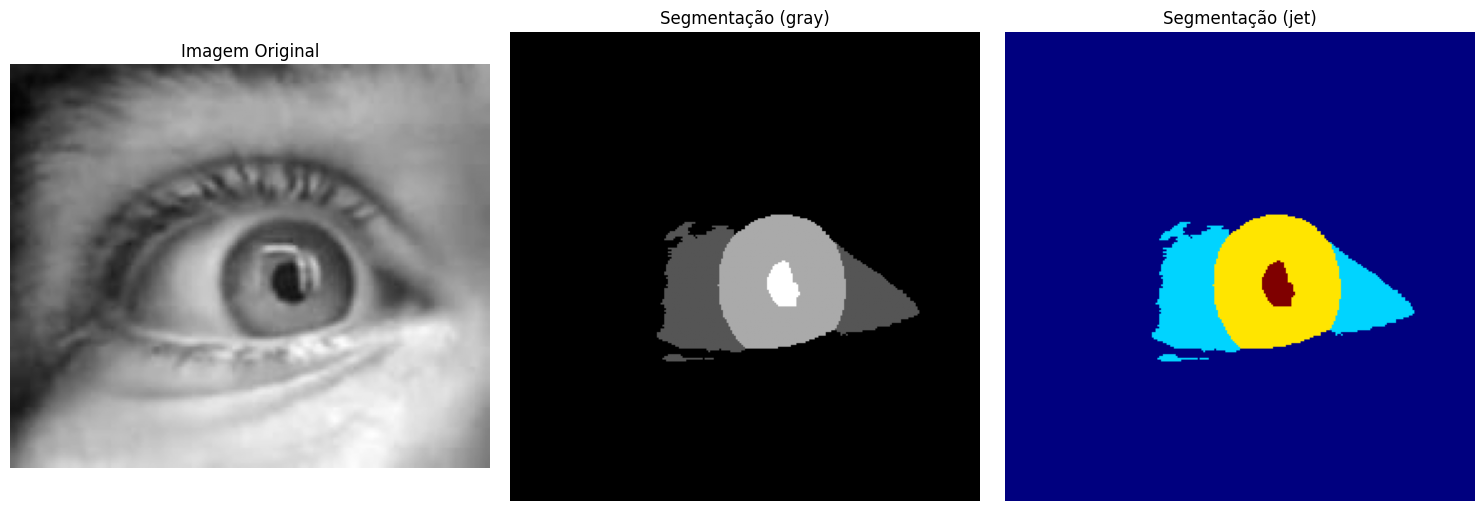

In [132]:
row = df.iloc[0]
seg = decode_to_cv2(row['segmentacao_base64'])
seg_gray = to_gray(seg)
img_cv = decode_to_cv2(row['img_base64'])

print(f'Imagem - shape: {img_cv.shape}, dtype: {img_cv.dtype}')
print(f'Segmentação - shape: {seg.shape}, dtype: {seg.dtype}')
print(f'Valores únicos (gray): {np.unique(seg_gray)}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_img(axes[0], img_cv, 'Imagem Original')
show_img(axes[1], seg_gray, 'Segmentação (gray)')
axes[2].imshow(seg_gray, cmap='jet')
axes[2].set_title('Segmentação (jet)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## 2. Pipeline de detecção

Usa segmentação para estimar elipses iniciais, depois refina com bordas Canny da imagem real.

Para a **íris**, o anel de busca é **assimétrico**: procura bordas mais para dentro do que para fora da estimativa, evitando que pálpebras expandam a elipse.

In [141]:
def detect_pupil_iris(img_b64, seg_b64,
                      pupil_thresh=200, iris_thresh=150,
                      iris_erode=0):
    """
    Detecta pupila e iris.
    
    1. Segmentacao -> mascaras -> elipses iniciais
    2. Canny na imagem real -> refina ambas as elipses
       - Pupila: anel simetrico (margem igual para dentro e fora)
       - Iris: anel assimetrico (busca mais para DENTRO, pouco para fora)
         para evitar que palpebras expandam a elipse
    
    Parâmetros:
      pupil_thresh: limiar para pupila (branco)
      iris_thresh:  limiar para iris+pupila (nao-fundo)
      iris_erode:   pixels para erodir mascara da iris antes de ajustar
    """
    img_cv = decode_to_cv2(img_b64)
    seg_cv = decode_to_cv2(seg_b64)
    seg_gray = to_gray(seg_cv)
    
    h_img, w_img = img_cv.shape[:2]
    h_seg, w_seg = seg_gray.shape[:2]
    if (h_img, w_img) != (h_seg, w_seg):
        seg_gray = cv2.resize(seg_gray, (w_img, h_img), interpolation=cv2.INTER_NEAREST)
    
    # Mascaras
    pupil_mask = (seg_gray > pupil_thresh).astype(np.uint8) * 255
    iris_full_mask = (seg_gray > iris_thresh).astype(np.uint8) * 255
    
    # Limpar ruido
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    pupil_mask = cv2.morphologyEx(pupil_mask, cv2.MORPH_CLOSE, kernel)
    pupil_mask = cv2.morphologyEx(pupil_mask, cv2.MORPH_OPEN, kernel)
    iris_full_mask = cv2.morphologyEx(iris_full_mask, cv2.MORPH_CLOSE, kernel)
    iris_full_mask = cv2.morphologyEx(iris_full_mask, cv2.MORPH_OPEN, kernel)
    
    if iris_erode > 0:
        k_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (iris_erode*2+1, iris_erode*2+1))
        iris_full_mask = cv2.erode(iris_full_mask, k_erode)
    
    # Elipses iniciais pela segmentacao
    pupil_ellipse = _fit_largest_ellipse(pupil_mask)
    iris_ellipse = _fit_largest_ellipse(iris_full_mask)
    
    # Bordas Canny da imagem real
    img_gray = to_gray(img_cv)
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    edges = cv2.Canny(img_blur, 30, 80)
    
    # Refinar PUPILA: anel simetrico
    if pupil_ellipse is not None:
        pupil_ellipse = _refine_ellipse(edges, pupil_ellipse,
                                        margin_in=15, margin_out=15)
    
    # Refinar IRIS: anel assimetrico (busca mais para dentro, pouco para fora)
    if iris_ellipse is not None:
        iris_ellipse = _refine_ellipse(edges, iris_ellipse,
                                       margin_in=20, margin_out=5)
    
    # Desenhar resultado
    img_result = to_bgr(img_cv)
    if pupil_ellipse is not None:
        cv2.ellipse(img_result, pupil_ellipse, (0, 255, 0), 2)
        c = (int(pupil_ellipse[0][0]), int(pupil_ellipse[0][1]))
        cv2.circle(img_result, c, 3, (0, 255, 0), -1)
    if iris_ellipse is not None:
        cv2.ellipse(img_result, iris_ellipse, (255, 0, 0), 2)
        c = (int(iris_ellipse[0][0]), int(iris_ellipse[0][1]))
        cv2.circle(img_result, c, 3, (255, 0, 0), -1)
    
    img_result_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
    return img_result_rgb, pupil_ellipse, iris_ellipse


def _fit_largest_ellipse(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        if len(cnt) >= 5:
            return cv2.fitEllipse(cnt)
    return None


def _refine_ellipse(edges, ellipse_est, margin_in=15, margin_out=15):
    """
    Refina elipse usando bordas Canny.
    
    O anel de busca e assimetrico:
      - margin_in:  quantos pixels para DENTRO da elipse estimada
      - margin_out: quantos pixels para FORA da elipse estimada
    
    Para a iris, usar margin_out pequeno evita que bordas de
    palpebras expandam a elipse.
    """
    center, axes, angle = ellipse_est
    cx, cy = int(center[0]), int(center[1])
    ax, ay = int(axes[0] / 2), int(axes[1] / 2)
    
    h, w = edges.shape[:2]
    mask_outer = np.zeros((h, w), dtype=np.uint8)
    mask_inner = np.zeros((h, w), dtype=np.uint8)
    
    # Anel: de (elipse - margin_in) ate (elipse + margin_out)
    cv2.ellipse(mask_outer, (cx, cy),
                (ax + margin_out, ay + margin_out),
                angle, 0, 360, 255, -1)
    cv2.ellipse(mask_inner, (cx, cy),
                (max(ax - margin_in, 1), max(ay - margin_in, 1)),
                angle, 0, 360, 255, -1)
    
    ring_mask = cv2.subtract(mask_outer, mask_inner)
    
    edge_points = np.column_stack(np.where((edges > 0) & (ring_mask > 0)))
    
    if len(edge_points) >= 5:
        pts = edge_points[:, ::-1].reshape(-1, 1, 2).astype(np.int32)
        try:
            refined = cv2.fitEllipse(pts)
            rc, raxes, _ = refined
            dist = np.sqrt((rc[0] - center[0])**2 + (rc[1] - center[1])**2)
            size_ratio = max(raxes) / (max(axes) + 1e-6)
            if dist < max(axes) * 0.5 and 0.5 < size_ratio < 1.5:
                return refined
        except:
            pass
    
    return ellipse_est

## 3. Testar a detecção

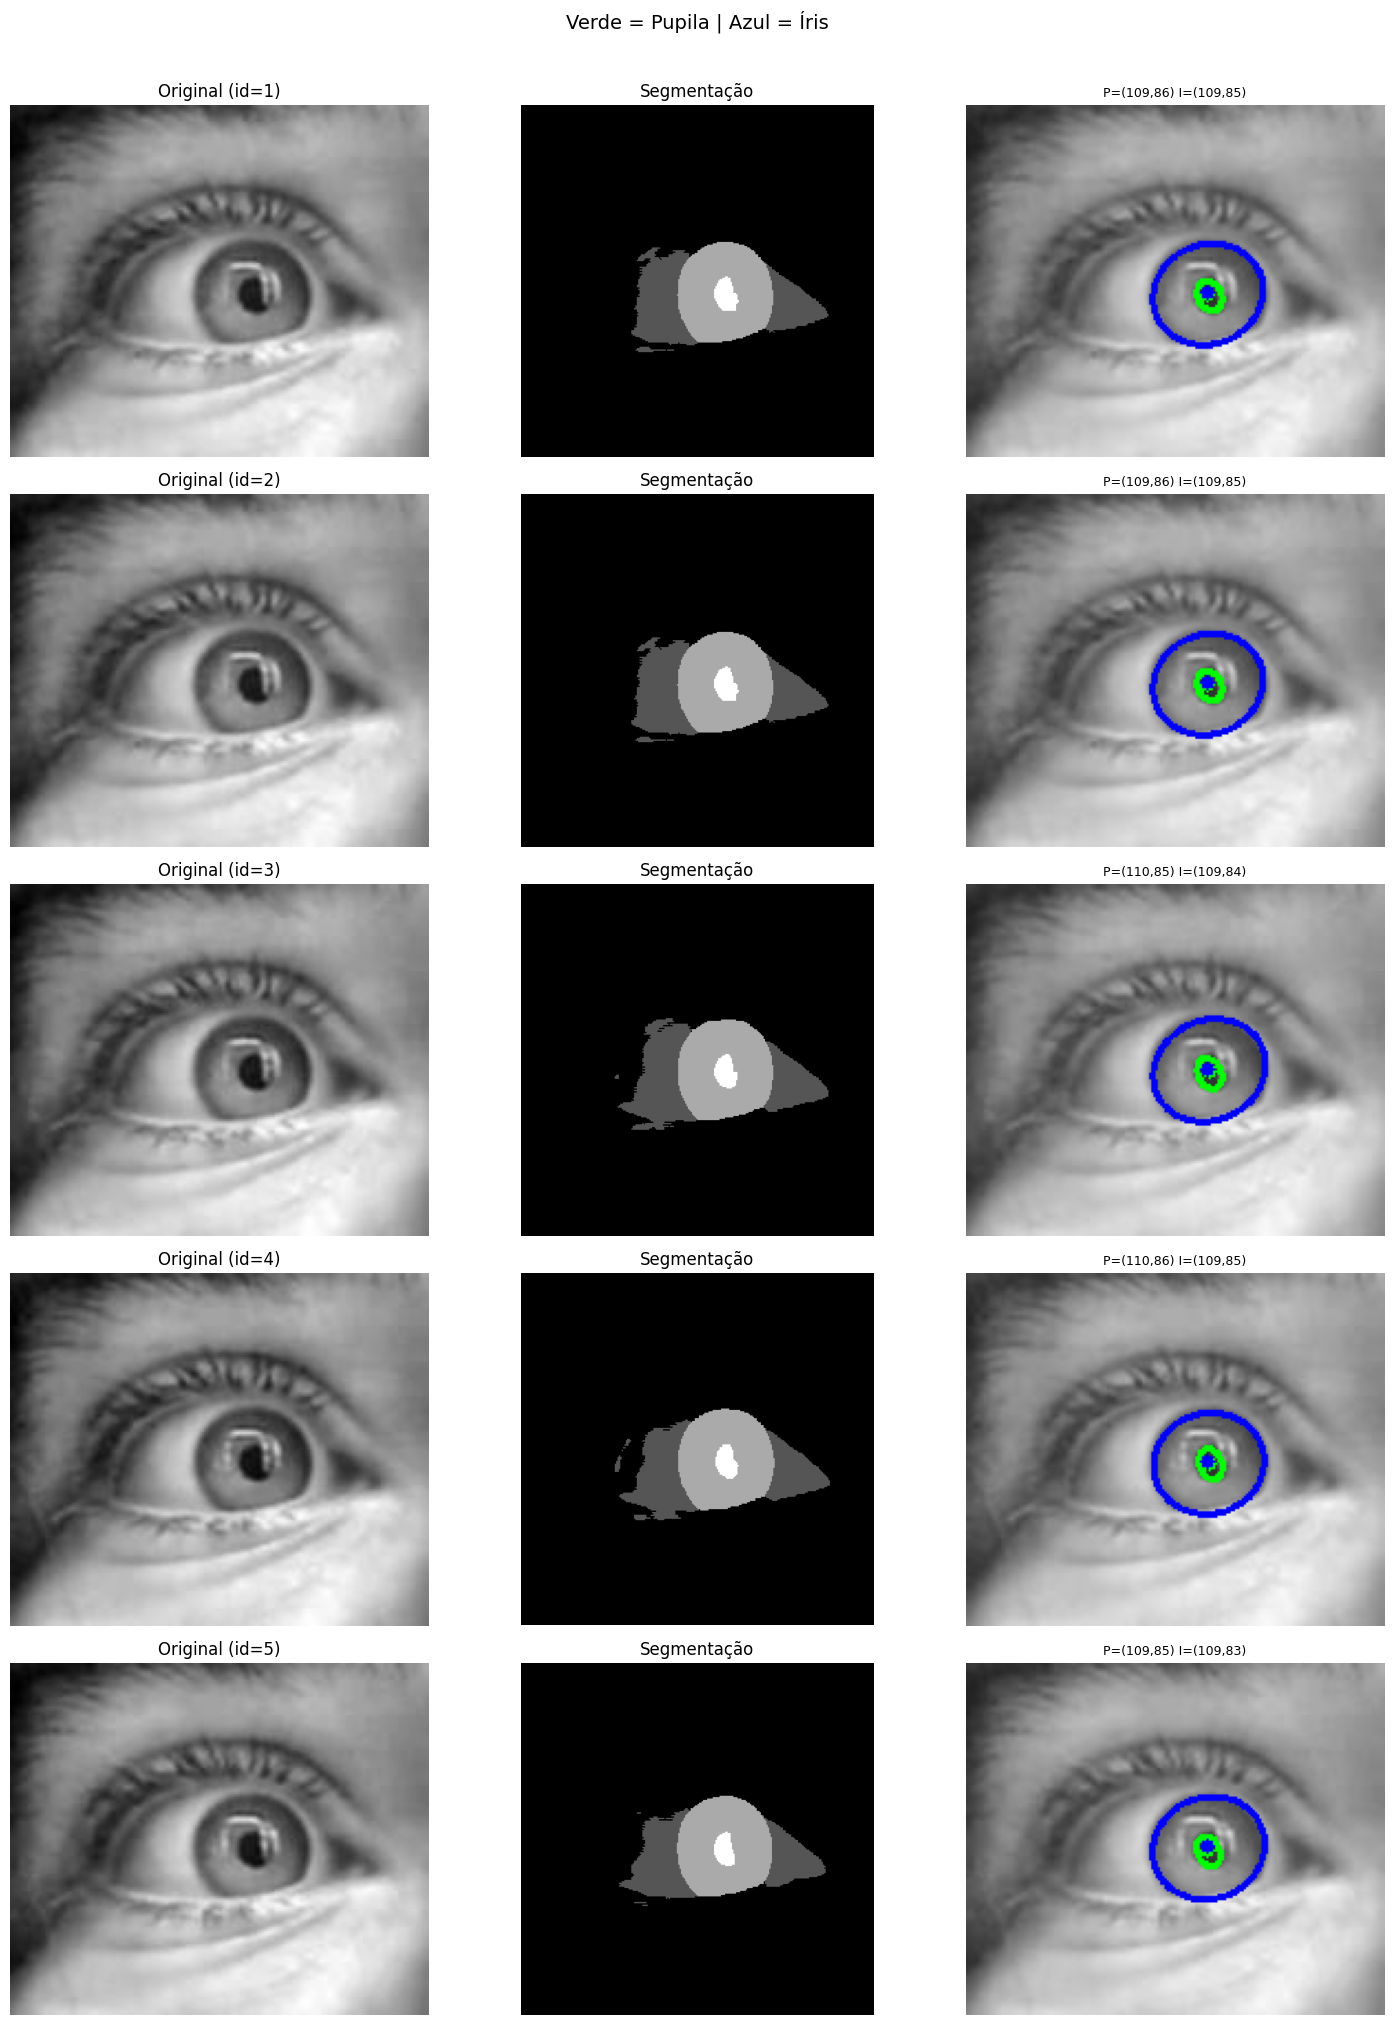

In [142]:
n = min(5, len(df))
fig, axes = plt.subplots(n, 3, figsize=(15, 4 * n))
if n == 1:
    axes = [axes]

for i in range(n):
    row = df.iloc[i]
    img_cv = decode_to_cv2(row['img_base64'])
    show_img(axes[i][0], img_cv, f"Original (id={row['data_id']})")
    
    seg_cv = decode_to_cv2(row['segmentacao_base64'])
    show_img(axes[i][1], to_gray(seg_cv), 'Segmentação')
    
    result, p_ell, i_ell = detect_pupil_iris(row['img_base64'], row['segmentacao_base64'])
    axes[i][2].imshow(result)
    title = ''
    if p_ell:
        title += f'P=({int(p_ell[0][0])},{int(p_ell[0][1])}) '
    if i_ell:
        title += f'I=({int(i_ell[0][0])},{int(i_ell[0][1])})'
    axes[i][2].set_title(title, fontsize=9)
    axes[i][2].axis('off')

plt.suptitle('Verde = Pupila | Azul = Íris', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Debug: máscaras, bordas e anel de busca

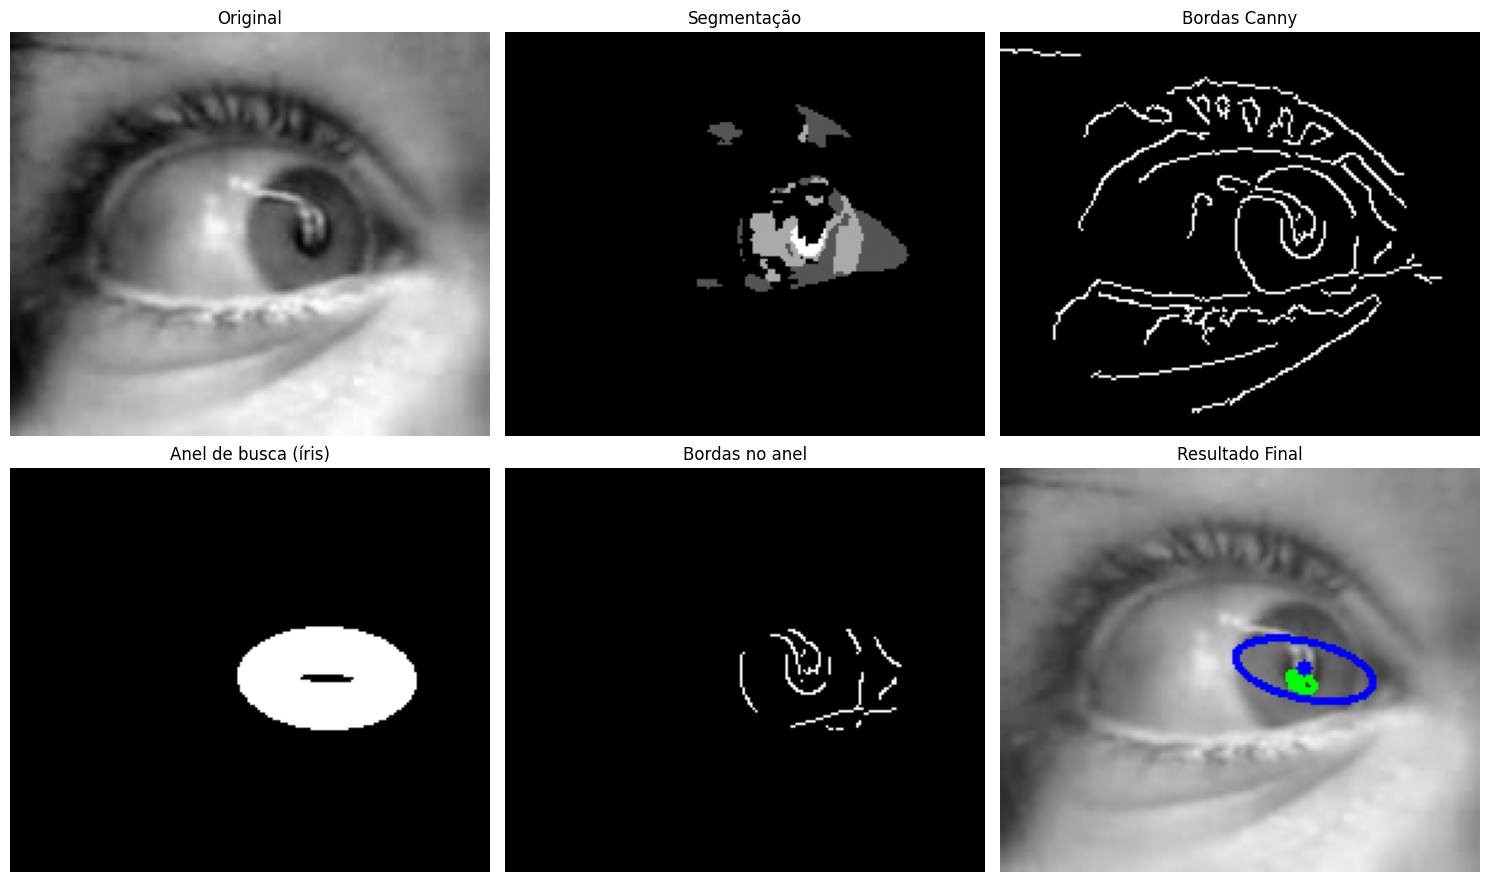

In [149]:
row = df.iloc[420]
img_cv = decode_to_cv2(row['img_base64'])
seg_gray = to_gray(decode_to_cv2(row['segmentacao_base64']))

h_img, w_img = img_cv.shape[:2]
if seg_gray.shape[:2] != (h_img, w_img):
    seg_gray = cv2.resize(seg_gray, (w_img, h_img), interpolation=cv2.INTER_NEAREST)

pupil_mask = (seg_gray > 200).astype(np.uint8) * 255
iris_full = (seg_gray > 50).astype(np.uint8) * 255

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
pupil_mask = cv2.morphologyEx(pupil_mask, cv2.MORPH_CLOSE, kernel)
pupil_mask = cv2.morphologyEx(pupil_mask, cv2.MORPH_OPEN, kernel)
iris_full = cv2.morphologyEx(iris_full, cv2.MORPH_CLOSE, kernel)
iris_full = cv2.morphologyEx(iris_full, cv2.MORPH_OPEN, kernel)

img_gray = to_gray(img_cv)
edges = cv2.Canny(cv2.GaussianBlur(img_gray, (7, 7), 0), 30, 80)

# Visualizar o anel de busca da iris
iris_ell = _fit_largest_ellipse(iris_full)
ring_vis = np.zeros_like(img_gray)
if iris_ell:
    cx, cy = int(iris_ell[0][0]), int(iris_ell[0][1])
    ax, ay = int(iris_ell[1][0]/2), int(iris_ell[1][1]/2)
    ang = iris_ell[2]
    outer = np.zeros_like(ring_vis)
    inner = np.zeros_like(ring_vis)
    cv2.ellipse(outer, (cx, cy), (ax + 5, ay + 5), ang, 0, 360, 255, -1)
    cv2.ellipse(inner, (cx, cy), (max(ax - 20, 1), max(ay - 20, 1)), ang, 0, 360, 255, -1)
    ring_vis = cv2.subtract(outer, inner)

# Bordas dentro do anel
edges_in_ring = cv2.bitwise_and(edges, ring_vis)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
show_img(axes[0][0], img_cv, 'Original')
show_img(axes[0][1], seg_gray, 'Segmentação')
show_img(axes[0][2], edges, 'Bordas Canny')
show_img(axes[1][0], ring_vis, 'Anel de busca (íris)')
show_img(axes[1][1], edges_in_ring, 'Bordas no anel')

result, _, _ = detect_pupil_iris(row['img_base64'], row['segmentacao_base64'])
axes[1][2].imshow(result)
axes[1][2].set_title('Resultado Final')
axes[1][2].axis('off')
plt.tight_layout()
plt.show()

## 5. Ajustar parâmetros

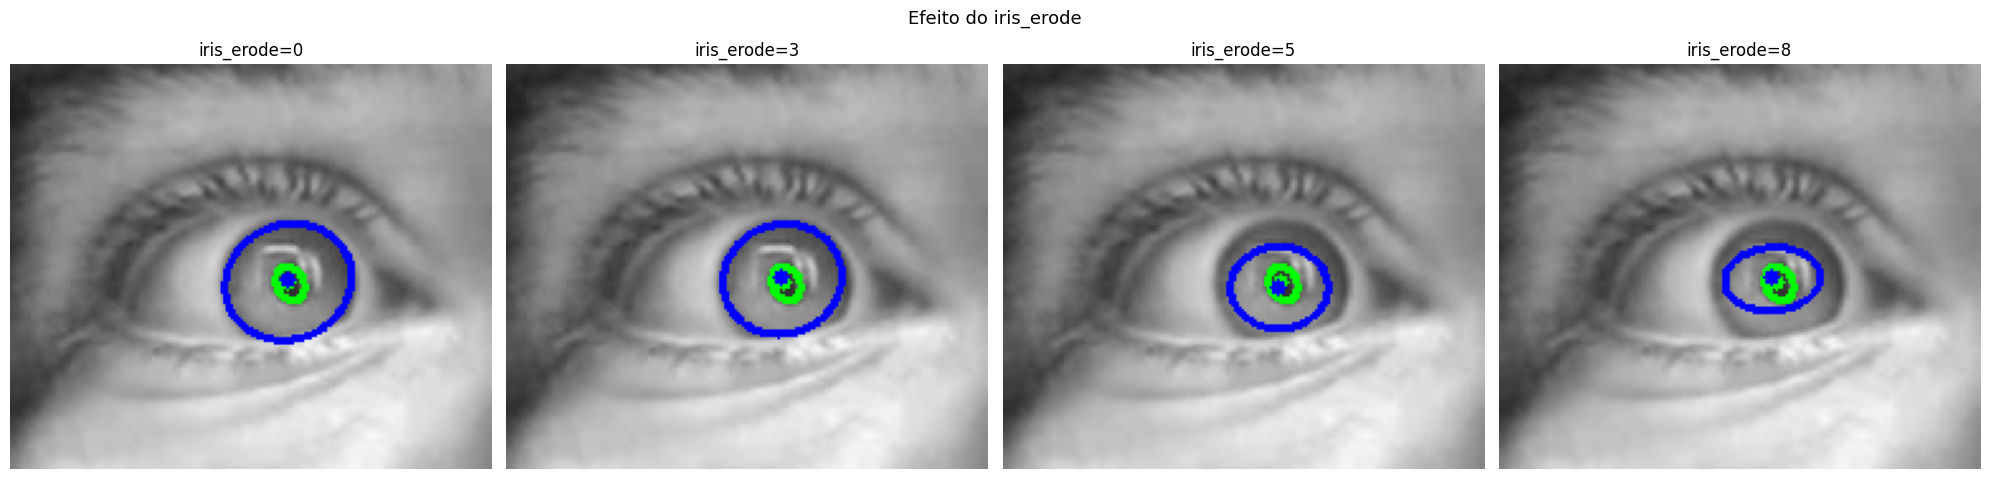

In [144]:
# Comparar diferentes valores de iris_erode
row = df.iloc[0]
erode_values = [0, 3, 5, 8]

fig, axes = plt.subplots(1, len(erode_values), figsize=(5 * len(erode_values), 5))
for idx, erode in enumerate(erode_values):
    result, _, _ = detect_pupil_iris(
        row['img_base64'], row['segmentacao_base64'], iris_erode=erode)
    axes[idx].imshow(result)
    axes[idx].set_title(f'iris_erode={erode}')
    axes[idx].axis('off')
plt.suptitle('Efeito do iris_erode', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Posição do olhar (centro da pupila) ao longo do tempo

Processa todos os frames, extrai o centro da pupila e da íris, e plota X e Y vs tempo.

In [145]:
# Processar todos os frames
tempos = []
pupil_x = []
pupil_y = []
iris_x = []
iris_y = []

for idx, row in df.iterrows():
    _, p_ell, i_ell = detect_pupil_iris(
        row['img_base64'], row['segmentacao_base64'])
    
    tempos.append(row['tempo'])
    
    if p_ell is not None:
        pupil_x.append(p_ell[0][0])
        pupil_y.append(p_ell[0][1])
    else:
        pupil_x.append(np.nan)
        pupil_y.append(np.nan)
    
    if i_ell is not None:
        iris_x.append(i_ell[0][0])
        iris_y.append(i_ell[0][1])
    else:
        iris_x.append(np.nan)
        iris_y.append(np.nan)

tempos = np.array(tempos)
pupil_x = np.array(pupil_x)
pupil_y = np.array(pupil_y)
iris_x = np.array(iris_x)
iris_y = np.array(iris_y)

print(f'Processados {len(tempos)} frames')
print(f'Pupila detectada em {np.count_nonzero(~np.isnan(pupil_x))}/{len(tempos)} frames')
print(f'Íris detectada em {np.count_nonzero(~np.isnan(iris_x))}/{len(tempos)} frames')

Processados 500 frames
Pupila detectada em 495/500 frames
Íris detectada em 500/500 frames


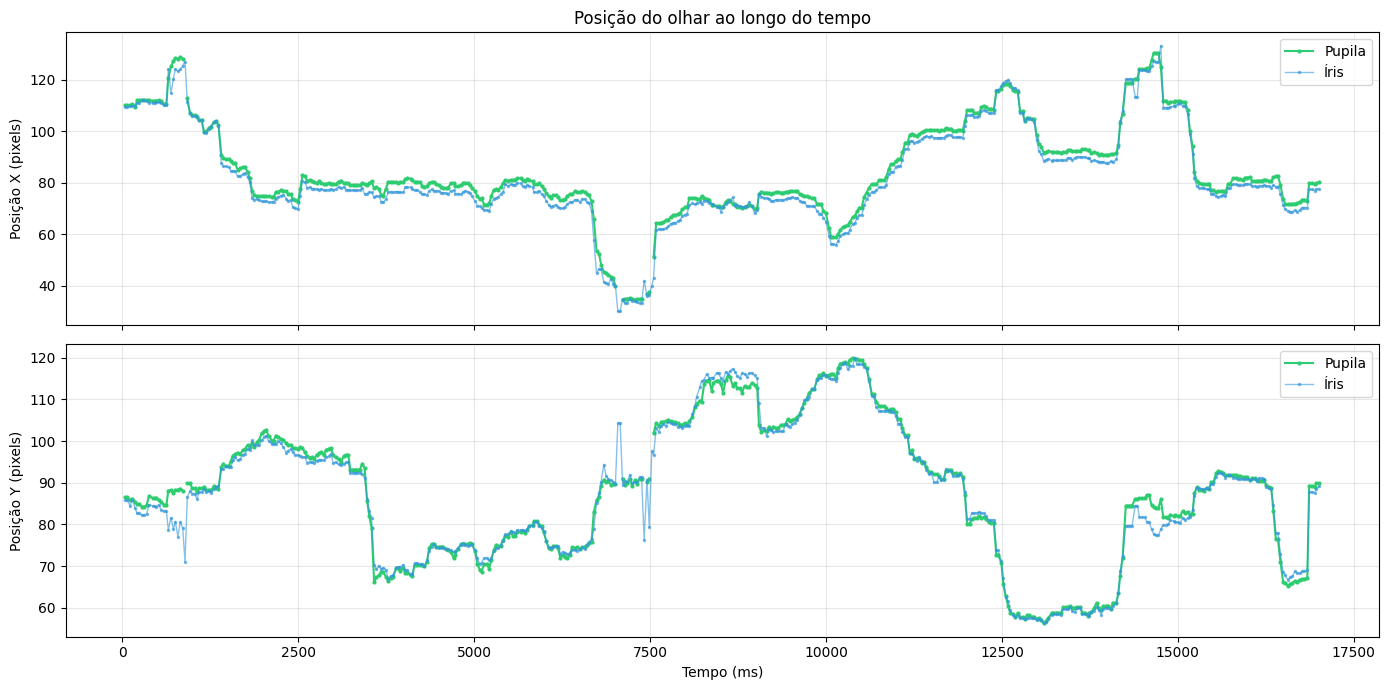

In [146]:
# Posicao X e Y ao longo do tempo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(tempos, pupil_x, '.-', color='#2ecc71', linewidth=1.5,
         markersize=4, label='Pupila')
ax1.plot(tempos, iris_x, '.-', color='#3498db', linewidth=1,
         markersize=3, alpha=0.6, label='Íris')
ax1.set_ylabel('Posição X (pixels)')
ax1.set_title('Posição do olhar ao longo do tempo')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(tempos, pupil_y, '.-', color='#2ecc71', linewidth=1.5,
         markersize=4, label='Pupila')
ax2.plot(tempos, iris_y, '.-', color='#3498db', linewidth=1,
         markersize=3, alpha=0.6, label='Íris')
ax2.set_ylabel('Posição Y (pixels)')
ax2.set_xlabel('Tempo (ms)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

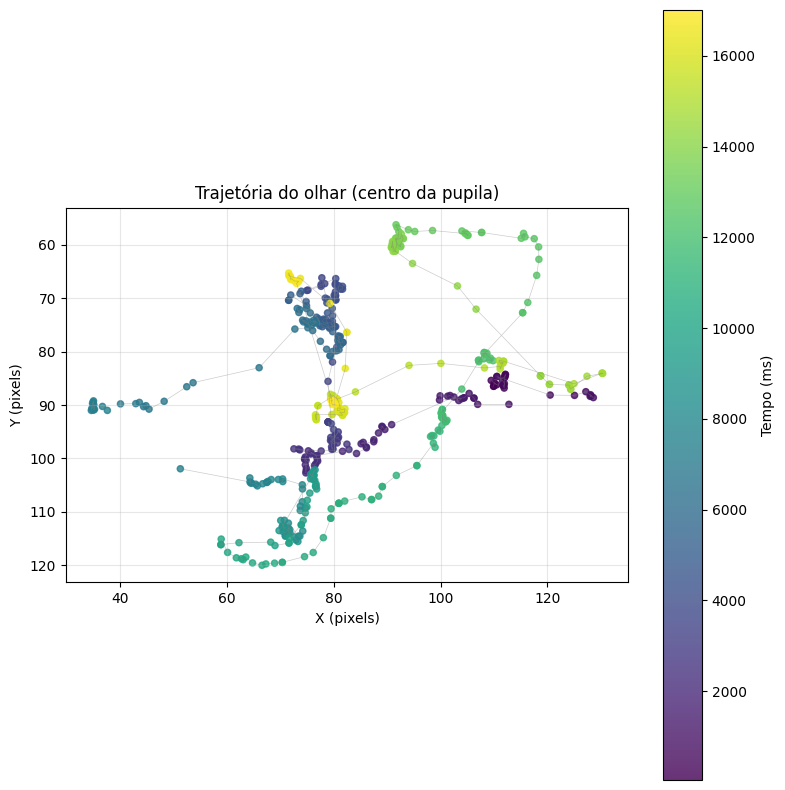

In [147]:
# Trajetoria XY do olhar
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(pupil_x, pupil_y, c=tempos, cmap='viridis',
                s=20, alpha=0.8)
ax.plot(pupil_x, pupil_y, '-', color='gray', linewidth=0.5, alpha=0.4)

plt.colorbar(sc, ax=ax, label='Tempo (ms)')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_title('Trajetória do olhar (centro da pupila)')
ax.invert_yaxis()  # Y cresce para baixo na imagem
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()